In [1]:
import pandas as pd
import numpy as np
import random
import csv
import matplotlib.pyplot as plt

print("Environment is ready!")

Environment is ready!


In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display the first 5 rows
print(df.head())

# Check number of rows and columns
print("\nDataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [4]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
df.to_csv("iris.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [6]:
# Select the column used for stratification
stratum_col = "species"

# Take 20% from each species group
stratified_sample = (
    df.groupby(stratum_col, group_keys=False)
      .sample(frac=0.20, random_state=42)
)

# Display the sample
print(stratified_sample.head(10))

# Check sample size
print("\nSample size:", len(stratified_sample))

    sepal_length  sepal_width  petal_length  petal_width species
13           4.3          3.0           1.1          0.1  setosa
39           5.1          3.4           1.5          0.2  setosa
30           4.8          3.1           1.6          0.2  setosa
45           4.8          3.0           1.4          0.3  setosa
17           5.1          3.5           1.4          0.3  setosa
48           5.3          3.7           1.5          0.2  setosa
26           5.0          3.4           1.6          0.4  setosa
25           5.0          3.0           1.6          0.2  setosa
32           5.2          4.1           1.5          0.1  setosa
19           5.1          3.8           1.5          0.3  setosa

Sample size: 30


In [7]:
print("Original distribution:")
print(df["species"].value_counts())

print("\nStratified sample distribution:")
print(stratified_sample["species"].value_counts())

Original distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Stratified sample distribution:
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64


In [8]:
original_proportions = (
    df["species"].value_counts(normalize=True)
)

sample_proportions = (
    stratified_sample["species"].value_counts(normalize=True)
)

proportion_comparison = pd.DataFrame({
    "Original": original_proportions,
    "Stratified Sample": sample_proportions
}).fillna(0)

print(proportion_comparison.round(3))

            Original  Stratified Sample
species                                
setosa         0.333              0.333
versicolor     0.333              0.333
virginica      0.333              0.333


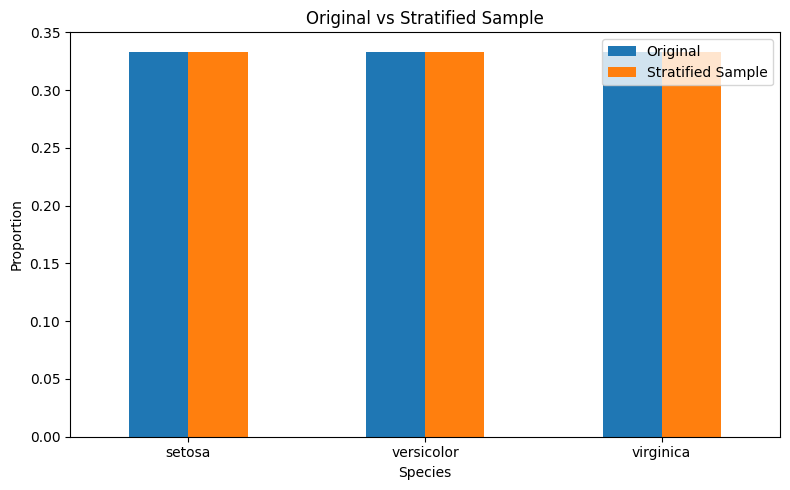

In [9]:
proportion_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Original vs Stratified Sample")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Stratified Sampling

Stratified sampling is a probability sampling technique in which the population is divided into separate groups called strata. A random sample is then selected from each group. In this experiment, the Iris dataset was divided into three strata based on the species column: setosa, versicolor, and virginica. A 20% sample was selected from each group, resulting in 10 records per species and 30 records overall. The sample preserved the original species proportions because the three groups were equally represented in the dataset.

In [10]:
import csv
import random
import pandas as pd

def reservoir_sampling(file_path, k, seed=42):
    rng = random.Random(seed)
    reservoir = []

    with open(file_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for i, row in enumerate(reader):

            # Fill the reservoir with the first k records
            if i < k:
                reservoir.append(row)

            else:
                # Generate a random position
                j = rng.randint(0, i)

                # Replace a record if the position is in the reservoir
                if j < k:
                    reservoir[j] = row

    return pd.DataFrame(reservoir)

In [11]:
# Use the same sample size as stratified sampling
k = len(stratified_sample)

reservoir_sample = reservoir_sampling(
    "iris.csv",
    k,
    seed=42
)

print("Reservoir sample size:", len(reservoir_sample))
print("\nFirst 5 records:")
print(reservoir_sample.head())

Reservoir sample size: 30

First 5 records:
  sepal_length sepal_width petal_length petal_width     species
0          6.1         2.9          4.7         1.4  versicolor
1          5.0         3.3          1.4         0.2      setosa
2          4.4         3.2          1.3         0.2      setosa
3          4.6         3.1          1.5         0.2      setosa
4          5.0         3.6          1.4         0.2      setosa


In [12]:
print("Reservoir sample distribution:")
print(reservoir_sample["species"].value_counts())

print("\nProportions:")
print(
    reservoir_sample["species"]
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Reservoir sample distribution:
species
versicolor    12
setosa        10
virginica      8
Name: count, dtype: int64

Proportions:
species
setosa        0.333
versicolor    0.400
virginica     0.267
Name: proportion, dtype: float64


In [13]:
print("Stratified sample:")
print(stratified_sample["species"].value_counts().sort_index())

print("\nReservoir sample:")
print(reservoir_sample["species"].value_counts().sort_index())

Stratified sample:
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64

Reservoir sample:
species
setosa        10
versicolor    12
virginica      8
Name: count, dtype: int64


### Reservoir Sampling

Reservoir sampling is a random sampling algorithm used to select a fixed number of records from a data stream when the total number of records may not be known in advance. In this experiment, the algorithm was implemented from scratch using Python's CSV reader and random number generator. The reservoir was initialized with the first 30 records, and each subsequent record had a chance to replace an existing record according to the algorithm. The final sample contained 30 records, without needing to load the entire CSV file into memory. Unlike stratified sampling, reservoir sampling does not guarantee a specific number of records from each species.

In [14]:
# Select the same number of records as the other methods
k = 30

random_sample = df.sample(
    n=k,
    random_state=42
)

print("Random sample size:", len(random_sample))

Random sample size: 30


In [15]:
print("Random sample distribution:")
print(random_sample["species"].value_counts().sort_index())

Random sample distribution:
species
setosa        10
versicolor     9
virginica     11
Name: count, dtype: int64


In [16]:
print("===== STRATIFIED SAMPLING =====")
print(stratified_sample["species"].value_counts().sort_index())

print("\n===== RESERVOIR SAMPLING =====")
print(reservoir_sample["species"].value_counts().sort_index())

print("\n===== FULL RANDOM SAMPLING =====")
print(random_sample["species"].value_counts().sort_index())

===== STRATIFIED SAMPLING =====
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64

===== RESERVOIR SAMPLING =====
species
setosa        10
versicolor    12
virginica      8
Name: count, dtype: int64

===== FULL RANDOM SAMPLING =====
species
setosa        10
versicolor     9
virginica     11
Name: count, dtype: int64


In [17]:
comparison_counts = pd.DataFrame({
    "Full Dataset": df["species"].value_counts(),
    "Stratified": stratified_sample["species"].value_counts(),
    "Reservoir": reservoir_sample["species"].value_counts(),
    "Full Random": random_sample["species"].value_counts()
}).fillna(0).astype(int)

print(comparison_counts)

            Full Dataset  Stratified  Reservoir  Full Random
species                                                     
setosa                50          10         10           10
versicolor            50          10         12            9
virginica             50          10          8           11


In [18]:
comparison_proportions = pd.DataFrame({
    "Full Dataset": df["species"].value_counts(normalize=True),
    "Stratified": stratified_sample["species"].value_counts(normalize=True),
    "Reservoir": reservoir_sample["species"].value_counts(normalize=True),
    "Full Random": random_sample["species"].value_counts(normalize=True)
}).fillna(0)

print(comparison_proportions.round(3))

            Full Dataset  Stratified  Reservoir  Full Random
species                                                     
setosa             0.333       0.333      0.333        0.333
versicolor         0.333       0.333      0.400        0.300
virginica          0.333       0.333      0.267        0.367


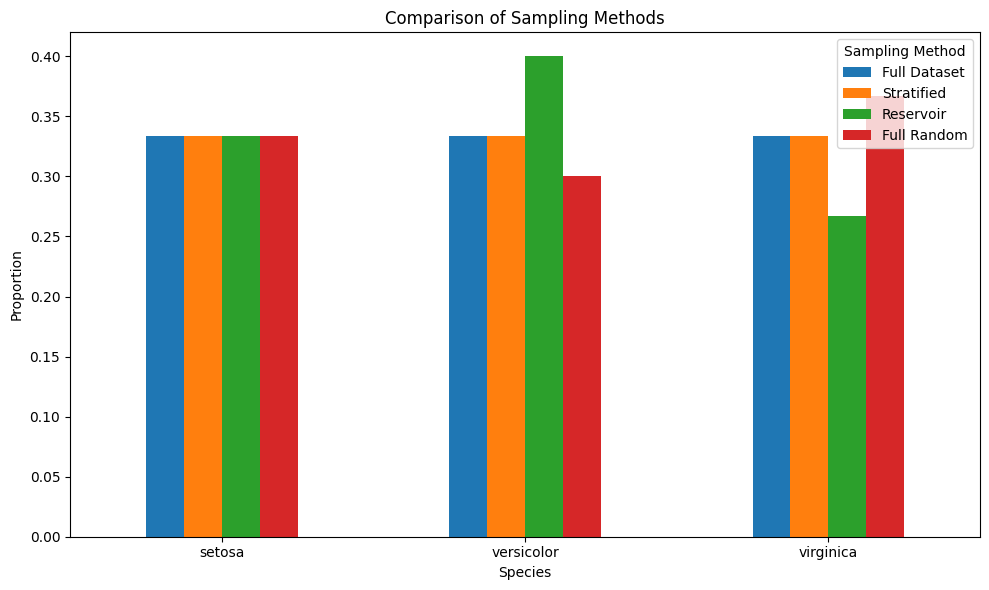

In [19]:
comparison_proportions.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Sampling Methods")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sampling Method")
plt.tight_layout()
plt.show()

Comparison of Sampling Methods
Three sampling methods were compared using the Iris dataset: stratified sampling, reservoir sampling, and full random sampling. All three methods produced a sample containing 30 records. Stratified sampling maintained the original species proportions by selecting 10 records from each species. Reservoir sampling and full random sampling selected records randomly from the complete dataset, so their species proportions could differ slightly from the original distribution. This demonstrates that stratified sampling provides explicit control over the representation of known groups, whereas reservoir sampling is designed for obtaining a fixed-size random sample from a data stream.

In [20]:
numeric_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Calculate original dataset means
original_means = df[numeric_cols].mean()

print("Original dataset means:")
print(original_means.round(3))

Original dataset means:
sepal_length    5.843
sepal_width     3.057
petal_length    3.758
petal_width     1.199
dtype: float64


In [21]:
numeric_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

for col in numeric_cols:
    reservoir_sample[col] = pd.to_numeric(
        reservoir_sample[col]
    )

print(reservoir_sample[numeric_cols].dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object


In [22]:
mean_comparison = pd.DataFrame({
    "Full Dataset": df[numeric_cols].mean(),
    "Stratified": stratified_sample[numeric_cols].mean(),
    "Reservoir": reservoir_sample[numeric_cols].mean(),
    "Full Random": random_sample[numeric_cols].mean()
})

print(mean_comparison.round(3))

              Full Dataset  Stratified  Reservoir  Full Random
sepal_length         5.843       5.883      5.933        5.980
sepal_width          3.057       3.057      3.023        3.040
petal_length         3.758       3.850      3.790        3.883
petal_width          1.199       1.183      1.180        1.263


In [23]:
absolute_error = mean_comparison.drop(
    columns=["Full Dataset"]
).subtract(
    mean_comparison["Full Dataset"],
    axis=0
).abs()

print(absolute_error.round(3))
print("\nAverage absolute error:")
print(absolute_error.mean().round(4))

              Stratified  Reservoir  Full Random
sepal_length       0.040      0.090        0.137
sepal_width        0.001      0.034        0.017
petal_length       0.092      0.032        0.125
petal_width        0.016      0.019        0.064

Average absolute error:
Stratified     0.0372
Reservoir      0.0438
Full Random    0.0858
dtype: float64


In [24]:
absolute_error = mean_comparison.drop(
    columns=["Full Dataset"]
).subtract(
    mean_comparison["Full Dataset"],
    axis=0
).abs()

print("Absolute error:")
print(absolute_error.round(3))

print("\nAverage absolute error:")
print(absolute_error.mean().round(4))

Absolute error:
              Stratified  Reservoir  Full Random
sepal_length       0.040      0.090        0.137
sepal_width        0.001      0.034        0.017
petal_length       0.092      0.032        0.125
petal_width        0.016      0.019        0.064

Average absolute error:
Stratified     0.0372
Reservoir      0.0438
Full Random    0.0858
dtype: float64


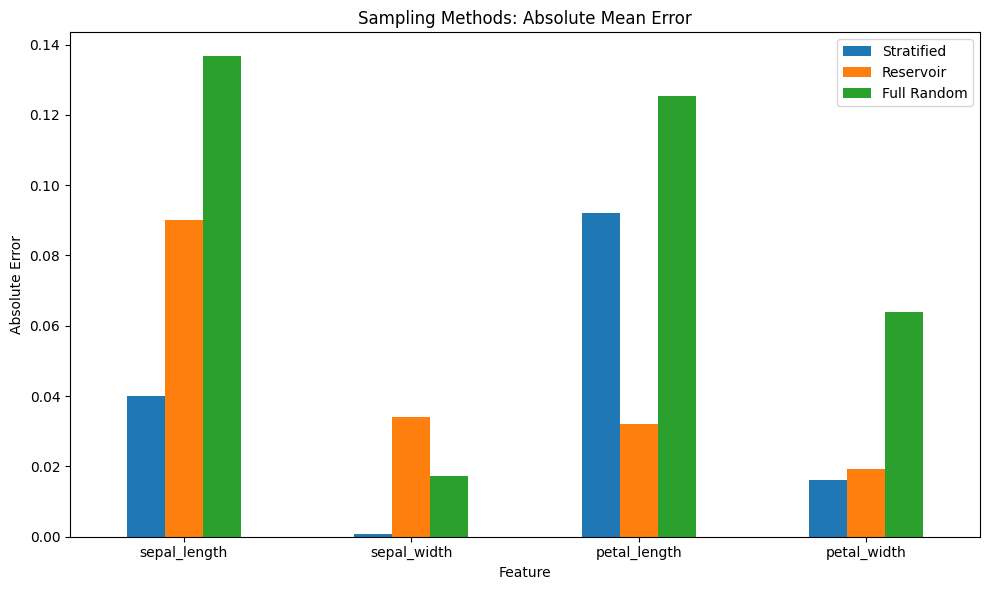

In [25]:
absolute_error.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sampling Methods: Absolute Mean Error")
plt.xlabel("Feature")
plt.ylabel("Absolute Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

This experiment compared stratified sampling, reservoir sampling, and full random sampling using the Iris dataset of 150 records, with each method producing a sample of 30 records. Stratified sampling selected 10 records from each species and preserved the original species distribution. In the numerical feature analysis, stratified sampling achieved an average absolute error of 0.0372, reservoir sampling achieved 0.0438, and full random sampling achieved 0.0858. Stratified sampling had the smallest average error in this experiment, while reservoir sampling had the smallest error for petal length. These findings illustrate that stratified sampling can preserve known group proportions, whereas reservoir sampling provides a fixed-size random sample from a stream without requiring the entire dataset to be loaded into memory. The results are specific to the samples generated and do not establish that one method will always have the smallest error.